In [1]:
from helpers import *
from ot_helpers import *
from ot_helpers import _build_cost_matrix

u0_sat.min: 0.0
u0_sat.max: 4.499614479587919
Initial mean of satellite density: 1.5011689328110223


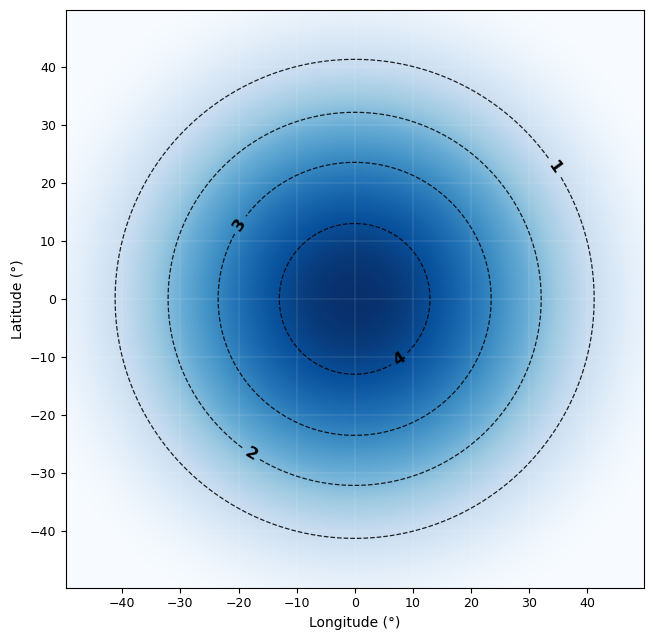

u0_doublegauss.min: 0.0
u0_doublegauss.max: 4.5
Initial mean of double Gauss density: 1.3047246904231182


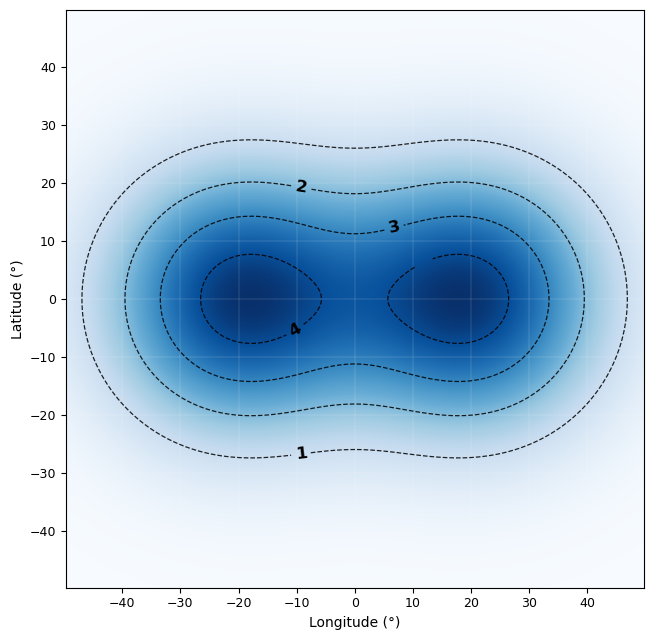

In [2]:
# initialize simulated densities
u0_sat, lons_sat, lats_sat = initial_meteosat_density()
print(f"u0_sat.min: {u0_sat.min()}")
print(f"u0_sat.max: {u0_sat.max()}")
print(f"Initial mean of satellite density: {u0_sat.mean()}")
plot_density_contour(u0_sat.T, lons_sat, lats_sat,
                               fontsize=12,
                               font_color='black',
                               line_color='black',
                               cmap='Blues')
plt.show()

u0_doublegauss, lons, lats = double_gaussian()
u0_doublegauss = scale_density(u0_doublegauss, target_min=0.0, target_max=4.5)
print(f"u0_doublegauss.min: {u0_doublegauss.min()}")
print(f"u0_doublegauss.max: {u0_doublegauss.max()}")
print(f"Initial mean of double Gauss density: {u0_doublegauss.mean()}")

plot_density_contour(u0_doublegauss, lons_sat, lats_sat,
                               fontsize=12,
                               font_color='black',
                               line_color='black',
                               cmap='Blues')
plt.show()

In [3]:
# parameters for the OT pipeline
Nx, Ny = u0_sat.shape   # 200 x 200
Nx_ot, Ny_ot = 64, 64
sinkhorn_reg = 0.005

In [4]:
# Build cost matrix once (shared for both densities)
# 64×64 instead of 200×200: exact OT (ot.emd) is O(n³) and Sinkhorn on 40k×40k is still prohibitive; 
# the coarse displacement is bilinearly upsampled afterward.
print("Building OT cost matrix...")
M_ot, grid_pts_ot, X_ot_grid, Y_ot_grid = _build_cost_matrix(Nx_ot, Ny_ot)

Building OT cost matrix...


Mean sat. density after Shirley-Chiu mapping: 1.5011689328110225


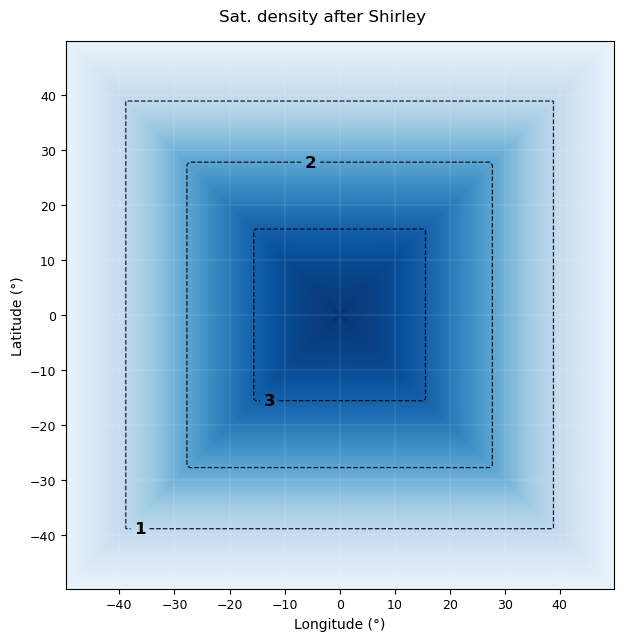

Mean double Gauss density after Shirley-Chiu mapping: 1.3047246904231182


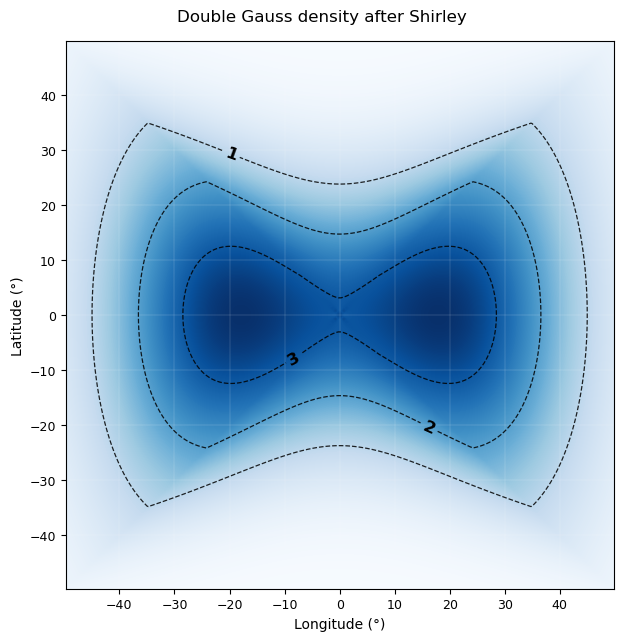

In [5]:
# Shirley mapping: disk FOV → filled square (same first step as SatFile)
# As it's the case with GN, OT won't move anything to zero-regions, 
# therefore Shirley-Chiu mapping and flooring prepares the density to contain only non-zero bins/pixels
shirley_sat   = shirley_map_density_to_square(u0_sat)
print(f"Mean sat. density after Shirley-Chiu mapping: {shirley_sat.mean()}")
plot_density_contour(shirley_sat, lons, lats, title="Sat. density after Shirley")
plt.show()

shirley_gauss = shirley_map_density_to_square(u0_doublegauss)
print(f"Mean double Gauss density after Shirley-Chiu mapping: {shirley_gauss.mean()}")
plot_density_contour(shirley_gauss, lons, lats, title="Double Gauss density after Shirley")
plt.show()

In [6]:
# with the densities prepared, lets run the OT pipeline to equalise the densities
print("\nRunning OT on Meteosat density...")
dX_sat, dY_sat, ot_density_sat = run_ot_pipeline(shirley_sat, u0_sat, Nx, Ny, Nx_ot, Ny_ot,
                                                    M_ot, grid_pts_ot, X_ot_grid, Y_ot_grid, reg=sinkhorn_reg)
print(f"Satellite density mean after OT: {ot_density_sat.mean()}")

print("\nRunning OT on double-Gaussian density...")
dX_doublegauss, dY_doublegauss, ot_density_doublegauss = run_ot_pipeline(shirley_gauss, u0_doublegauss, Nx, Ny, Nx_ot, Ny_ot,
                                                        M_ot, grid_pts_ot, X_ot_grid, Y_ot_grid, reg=sinkhorn_reg)
print(f"Doublegauss density mean after OT: {ot_density_doublegauss.mean()}")
# no need to plot the densities, as they become a constant value (per definition of OT)


Running OT on Meteosat density...
Satellite density mean after OT: 1.5011689328110225

Running OT on double-Gaussian density...
Doublegauss density mean after OT: 1.304724690423118


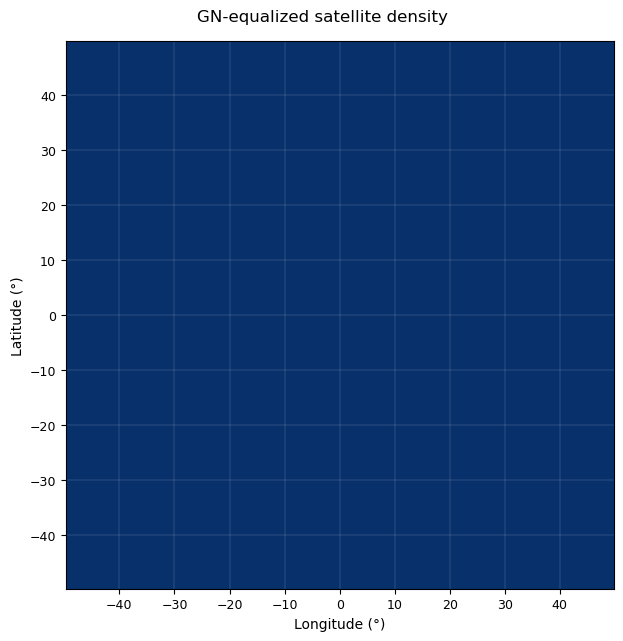

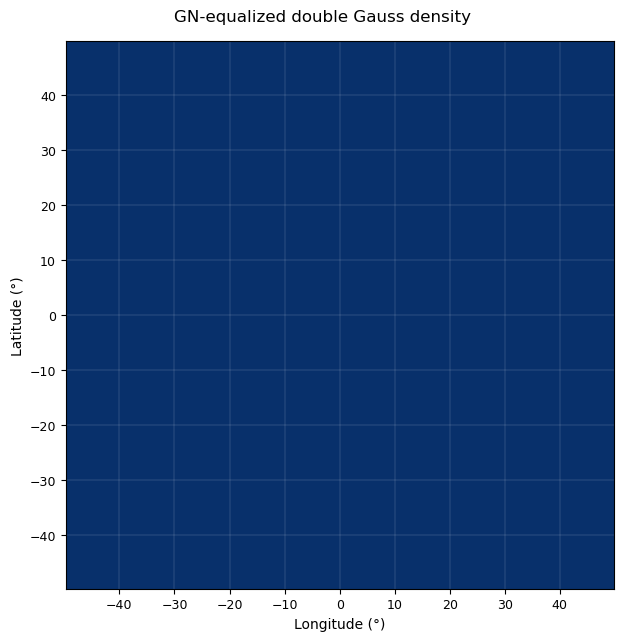

In [7]:
# plot the resulting densities after applying the OT algorithm
plot_density_contour(ot_density_sat, lons, lats, title="GN-equalized satellite density")
plt.show()

plot_density_contour(ot_density_doublegauss, lons, lats, title="GN-equalized double Gauss density")
plt.show()

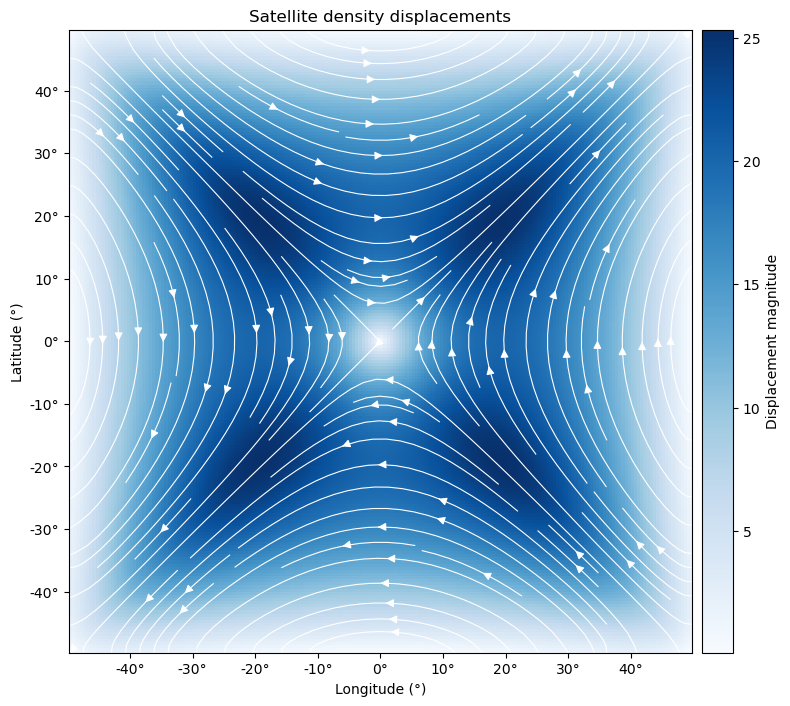

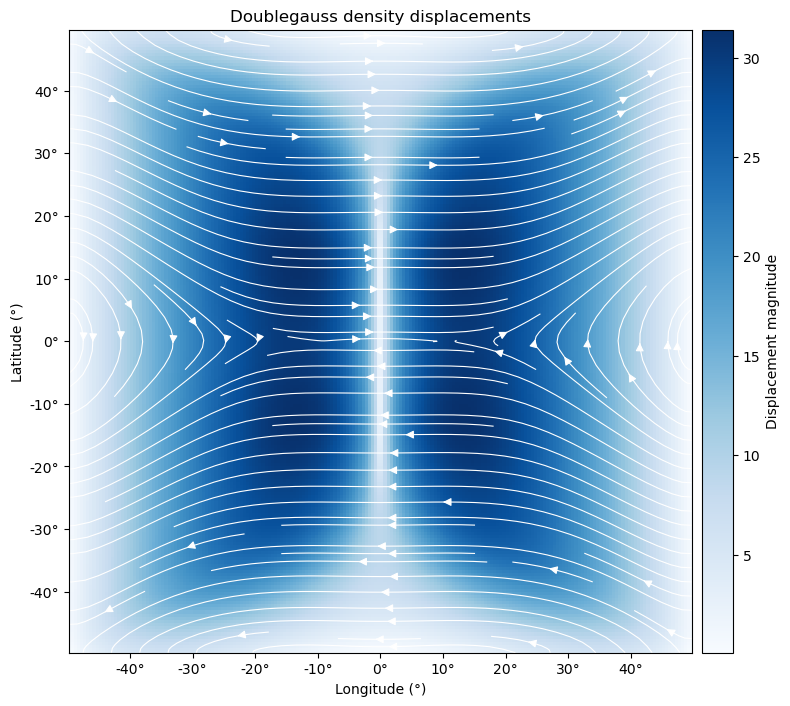

In [8]:
streamplot_displacements(lons, lats, dX_sat, dY_sat, title="Satellite density displacements")
streamplot_displacements(lons, lats, dX_doublegauss, dY_doublegauss, title="Doublegauss density displacements")

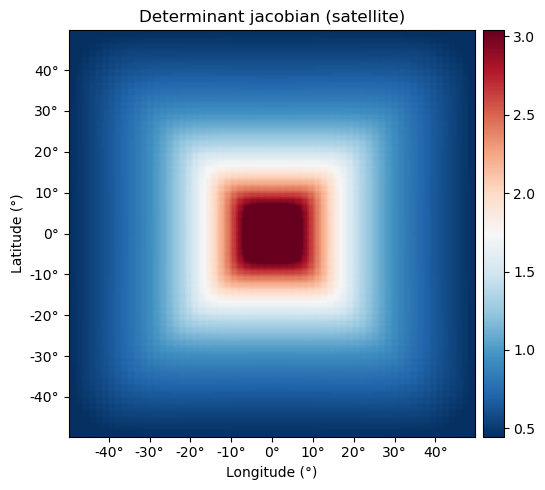

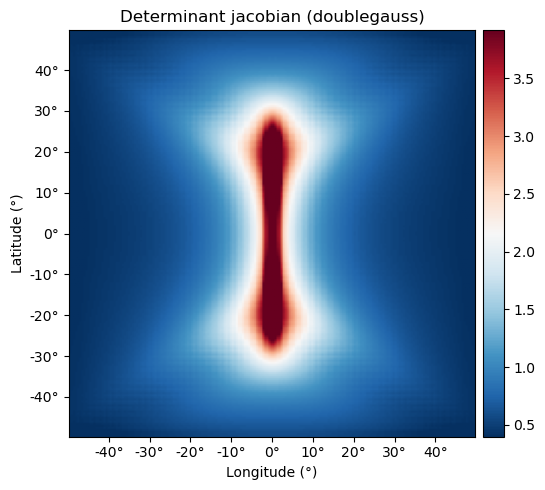

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Determinant jacobian (doublegauss)'}, xlabel='Longitude (°)', ylabel='Latitude (°)'>)

In [9]:
# now lets look at the jacobian and the determinant jacobian of the displacements field to determine if folds were created
displacement_jacobian_sat = compute_jacobian(dX_sat, dY_sat)
det_J_sat = displacement_jacobian(dX_sat, dY_sat)
plot_field(det_J_sat, cmap='RdBu_r', colorbar=True, lons=lons, lats=lats, title="Determinant jacobian (satellite)")

displacement_jacobian_doublegauss = compute_jacobian(dX_doublegauss, dY_doublegauss)
det_J_doublegauss = displacement_jacobian(dX_doublegauss, dY_doublegauss)
plot_field(det_J_doublegauss, cmap='RdBu_r', colorbar=True, lons=lons, lats=lats, title="Determinant jacobian (doublegauss)")

In [10]:
# looking at the values of the jacobian determinants, we expect no negative values to validate that the warp is fold-free
print(f"sat:   min={det_J_sat.min():.4f}, max={det_J_sat.max():.4f}, mean={det_J_sat.mean():.4f}, folds={(det_J_sat<=0).sum()}")
print(f"gauss: min={det_J_doublegauss.min():.4f}, max={det_J_doublegauss.max():.4f}, mean={det_J_doublegauss.mean():.4f}, folds={(det_J_doublegauss<=0).sum()}")

sat:   min=0.3349, max=6.5765, mean=0.9919, folds=0
gauss: min=0.3327, max=8.3493, mean=0.9902, folds=0
